🚀 월드컵 예측 (Enhanced Version) 시작...


✅ 피처 생성 완료 (학습: 49,405건 / 타겟: 72건)

[1/2] 홈팀 예측 모델 튜닝...

📊 [Home Goals Model] 피처 중요도 생성 중...


<Figure size 1000x500 with 0 Axes>

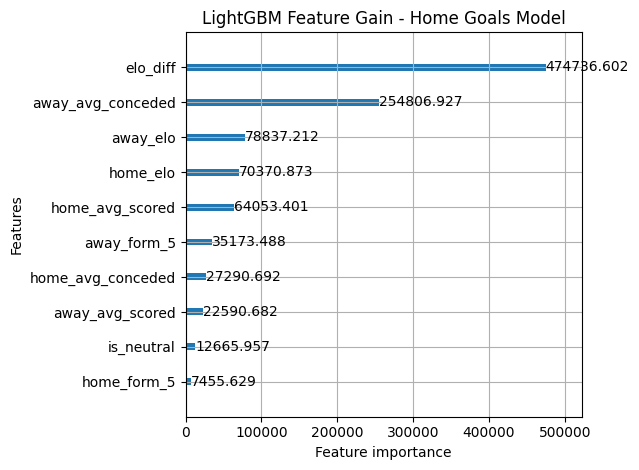

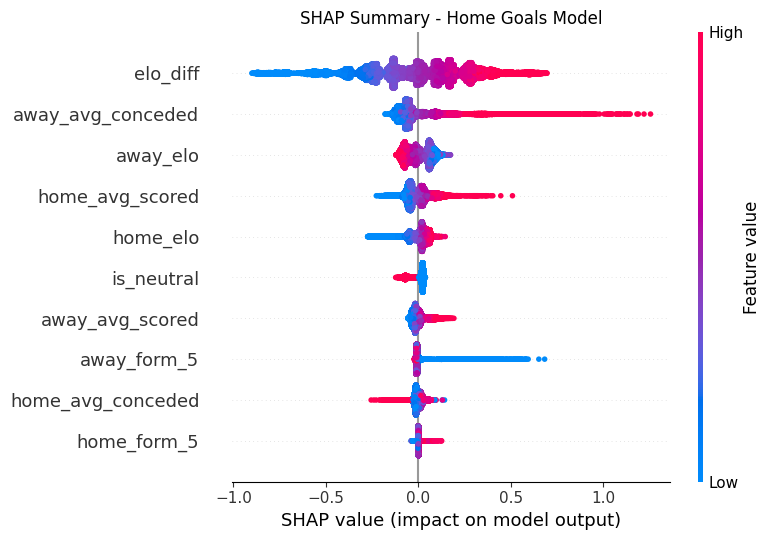


[2/2] 원정팀 예측 모델 튜닝...

📊 [Away Goals Model] 피처 중요도 생성 중...


<Figure size 1000x500 with 0 Axes>

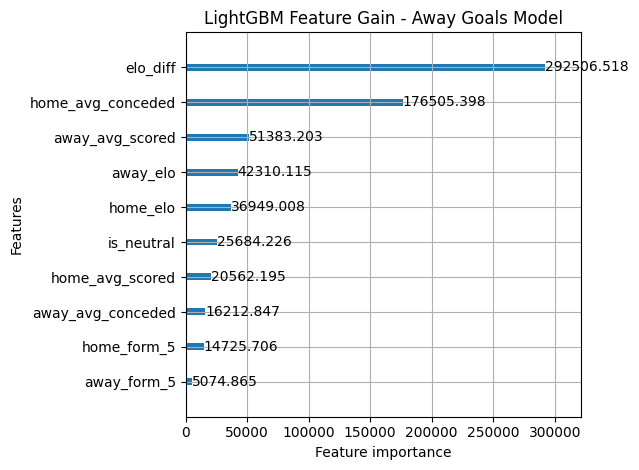

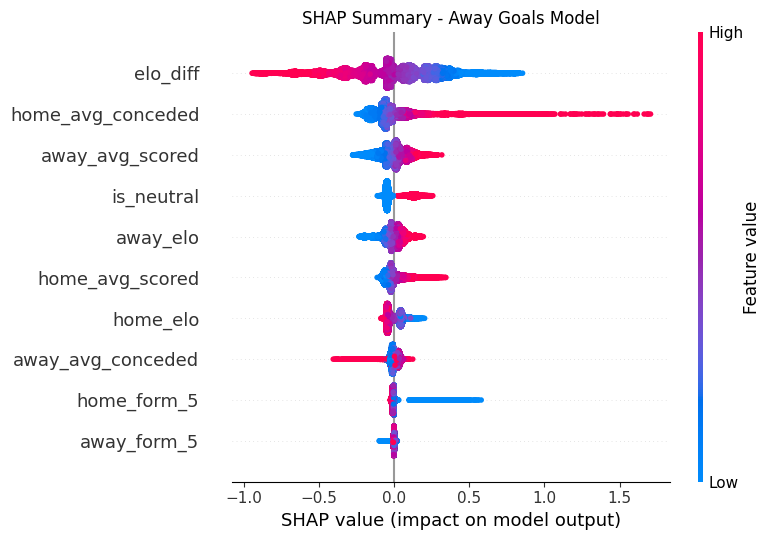


💾 모델 저장 완료 (lgb_home_model.txt, lgb_away_model.txt)

🏃‍♂️ 각 경기당 10,000번의 몬테카를로 시뮬레이션 중...


100%|██████████| 72/72 [00:00<00:00, 90.11it/s]


🎉 1차 예측 파일 저장 완료: submission_consensus_fixed.csv


In [ ]:
# ==============================================================================
# [CELL 1] 2026 FIFA World Cup - Advanced Prediction Pipeline (Visuals & Save)
# ==============================================================================
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------------------------------------------------
# 1. Advanced Feature Engineering (Dynamic Elo)
# ---------------------------------------------------------
class AdvancedElo:
    def __init__(self, k=20, base=1500):
        self.k = k
        self.ratings = {}
        self.base = base

    def get_rating(self, team):
        return self.ratings.get(team, self.base)

    def expected_result(self, loc, awc):
        dr = loc - awc
        return 1 / (10 ** (-dr / 400) + 1)

    def update_rating(self, home_team, away_team, home_goals, away_goals, tournament_weight=1.0):
        home_rating = self.get_rating(home_team)
        away_rating = self.get_rating(away_team)

        goal_diff = abs(home_goals - away_goals)
        if goal_diff <= 1: G = 1.0
        elif goal_diff == 2: G = 1.5
        else: G = (11 + goal_diff) / 8.0

        home_expected = self.expected_result(home_rating + 100, away_rating)
        away_expected = self.expected_result(away_rating, home_rating + 100)

        if home_goals > away_goals: home_actual, away_actual = 1, 0
        elif home_goals < away_goals: home_actual, away_actual = 0, 1
        else: home_actual, away_actual = 0.5, 0.5

        self.ratings[home_team] = home_rating + self.k * G * tournament_weight * (home_actual - home_expected)
        self.ratings[away_team] = away_rating + self.k * G * tournament_weight * (away_actual - away_expected)

# ---------------------------------------------------------
# 2. Model Training & Visualizations
# ---------------------------------------------------------
def optimize_and_train(X, y, n_trials=50):
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

    def objective(trial):
        params = {
            'objective': 'poisson', 'metric': 'poisson',
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'feature_pre_filter': False, 'verbose': -1, 'seed': 42
        }
        gbm = lgb.train(params, train_data, valid_sets=[valid_data], num_boost_round=2000,
                        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
        return gbm.best_score['valid_0']['poisson']

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    best_params = study.best_params
    best_params.update({'objective': 'poisson', 'feature_pre_filter': False, 'verbose': -1, 'seed': 42})
    return lgb.train(best_params, lgb.Dataset(X, label=y), num_boost_round=1000)

def visualize_importance(model, X, title):
    print(f"\n📊 [{title}] 피처 중요도 생성 중...")
    plt.figure(figsize=(10, 5))
    lgb.plot_importance(model, importance_type='gain', max_num_features=15, title=f"LightGBM Feature Gain - {title}")
    plt.tight_layout()
    plt.show()

    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        plt.figure(figsize=(10, 6))
        plt.title(f"SHAP Summary - {title}")
        shap.summary_plot(shap_values, X, show=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"SHAP 에러 (스킵): {e}")

def train_lgbm_models(df_train, n_trials=50):
    features = ['home_elo', 'away_elo', 'elo_diff', 'home_avg_scored', 'away_avg_conceded',
                'away_avg_scored', 'home_avg_conceded', 'home_form_5', 'away_form_5', 'is_neutral']
    
    X = df_train[features]
    print("\n[1/2] 홈팀 예측 모델 튜닝...")
    lgb_home = optimize_and_train(X, df_train['home_score'], n_trials)
    visualize_importance(lgb_home, X, "Home Goals Model")
    
    print("\n[2/2] 원정팀 예측 모델 튜닝...")
    lgb_away = optimize_and_train(X, df_train['away_score'], n_trials)
    visualize_importance(lgb_away, X, "Away Goals Model")

    return lgb_home, lgb_away, features

# ---------------------------------------------------------
# 3. Upgraded Simulation Engine (안정성 + 다양성)
# ---------------------------------------------------------
def simulate_match(lambda_home, lambda_away, n_simulations=10000):
    # Poisson 람다값을 바탕으로 시뮬레이션
    home_goals_sim = poisson.rvs(mu=lambda_home, size=n_simulations)
    away_goals_sim = poisson.rvs(mu=lambda_away, size=n_simulations)
    
    home_wins = np.sum(home_goals_sim > away_goals_sim)
    draws = np.sum(home_goals_sim == away_goals_sim)
    away_wins = np.sum(home_goals_sim < away_goals_sim)
    
    prob_h = home_wins / n_simulations
    prob_d = draws / n_simulations
    prob_a = away_wins / n_simulations
    
    # 💡 [업그레이드] 무조건 최빈값이 아닌, 상위 3개 스코어 중 확률적 샘플링
    scores = [f"{h}-{a}" for h, a in zip(home_goals_sim, away_goals_sim)]
    unique_scores, counts = np.unique(scores, return_counts=True)
    
    # 상위 3개 추출
    top_indices = np.argsort(counts)[-3:]
    top_scores = unique_scores[top_indices]
    top_probs = counts[top_indices] / np.sum(counts[top_indices])
    
    # 샘플링 (정배를 주로 고르지만, 가끔 무승부나 1점차 이변을 고르게 됨)
    predicted_score = np.random.choice(top_scores, p=top_probs)
    pred_h, pred_a = map(int, predicted_score.split('-'))
    
    return prob_h, prob_d, prob_a, pred_h, pred_a

def predict_tournament(test_matches, lgb_home, lgb_away, features, n_simulations=10000):
    X_test = test_matches[features]
    test_matches['lambda_home'] = lgb_home.predict(X_test)
    test_matches['lambda_away'] = lgb_away.predict(X_test)
    
    results = []
    print(f"\n🏃‍♂️ 각 경기당 {n_simulations:,}번의 몬테카를로 시뮬레이션 중...")
    
    for idx, row in tqdm(test_matches.iterrows(), total=len(test_matches)):
        p_home, p_draw, p_away, pred_h, pred_a = simulate_match(row['lambda_home'], row['lambda_away'], n_simulations)
        
        # 무승부 파이 비례 배분
        if (p_home + p_away) > 0:
            t1_prob = p_home + p_draw * (p_home / (p_home + p_away))
            t2_prob = p_away + p_draw * (p_away / (p_home + p_away))
        else:
            t1_prob, t2_prob = 0.5, 0.5
            
        if pred_h == pred_a:
            if t1_prob > t2_prob: pred_h += 1 
            elif t2_prob > t1_prob: pred_a += 1

        match_type = row.get('type', 'group')
        if pd.isna(match_type) or match_type == '': match_type = 'group'

        results.append({
            'team1': row['home_team'], 'team2': row['away_team'],
            'team1_score': int(pred_h), 'team2_score': int(pred_a),
            'team1_prob': round(t1_prob, 4), 'team2_prob': round(t2_prob, 4),
            'type': match_type
        })
        
    return pd.DataFrame(results, columns=['team1', 'team2', 'team1_score', 'team2_score', 'team1_prob', 'team2_prob', 'type'])

# ---------------------------------------------------------
# 4. Execution Pipeline
# ---------------------------------------------------------
if __name__ == "__main__":
    print("🚀 월드컵 예측 (Enhanced Version) 시작...\n")
    
    file_path = "/kaggle/input/datasets/dybalar/feature/historical_results.csv"
    df = pd.read_csv(file_path)
    
    name_corrections = {
        'Cura?ao': 'Curaçao', 'Curacao': 'Curaçao', 'DR Congo': 'Congo DR', 
        'Cape Verde': 'Cape Verde Islands', 'Czech Republic': 'Czechia',
        'Bosnia and Herzegovina': 'Bosnia-Herzegovina', 'Bosnia': 'Bosnia-Herzegovina'
    }
    df['home_team'] = df['home_team'].replace(name_corrections)
    df['away_team'] = df['away_team'].replace(name_corrections)

    df['home_score'] = pd.to_numeric(df['home_score'], errors='coerce')
    df['away_score'] = pd.to_numeric(df['away_score'], errors='coerce')
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df['is_neutral'] = df['neutral'].apply(lambda x: 1 if str(x).upper() == 'TRUE' else 0)

    elo_system = AdvancedElo()
    home_elos, away_elos, h_avg_s, h_avg_c, a_avg_s, a_avg_c, h_form, a_form = [], [], [], [], [], [], [], []
    team_stats = {}

    for idx, row in df.iterrows():
        ht, at = row['home_team'], row['away_team']
        home_elos.append(elo_system.get_rating(ht)); away_elos.append(elo_system.get_rating(at))
        for t in (ht, at):
            if t not in team_stats: team_stats[t] = {'scored': [], 'conceded': [], 'pts': []}
                
        if len(team_stats[ht]['scored']) > 0:
            h_avg_s.append(np.mean(team_stats[ht]['scored'][-10:])); h_avg_c.append(np.mean(team_stats[ht]['conceded'][-10:]))
            h_form.append(sum(team_stats[ht]['pts'][-5:]))
        else:
            h_avg_s.append(1.0); h_avg_c.append(1.0); h_form.append(0)
            
        if len(team_stats[at]['scored']) > 0:
            a_avg_s.append(np.mean(team_stats[at]['scored'][-10:])); a_avg_c.append(np.mean(team_stats[at]['conceded'][-10:]))
            a_form.append(sum(team_stats[at]['pts'][-5:]))
        else:
            a_avg_s.append(1.0); a_avg_c.append(1.0); a_form.append(0)

        if pd.notna(row['home_score']) and pd.notna(row['away_score']):
            hs, ast = float(row['home_score']), float(row['away_score'])
            elo_system.update_rating(ht, at, hs, ast)
            team_stats[ht]['scored'].append(hs); team_stats[ht]['conceded'].append(ast)
            team_stats[at]['scored'].append(ast); team_stats[at]['conceded'].append(hs)
            team_stats[ht]['pts'].append(3 if hs > ast else (0 if hs < ast else 1))
            team_stats[at]['pts'].append(0 if hs > ast else (3 if hs < ast else 1))

    df['home_elo'] = home_elos; df['away_elo'] = away_elos; df['elo_diff'] = df['home_elo'] - df['away_elo']
    df['home_avg_scored'] = h_avg_s; df['home_avg_conceded'] = h_avg_c
    df['away_avg_scored'] = a_avg_s; df['away_avg_conceded'] = a_avg_c
    df['home_form_5'] = h_form; df['away_form_5'] = a_form

    mask_2026_wc = (df['date'].dt.year == 2026) & (df['tournament'] == 'FIFA World Cup')
    df_train = df[~mask_2026_wc].dropna(subset=['home_score', 'away_score']).copy()
    df_test = df[mask_2026_wc].copy()
    
    print(f"\n✅ 피처 생성 완료 (학습: {len(df_train):,}건 / 타겟: {len(df_test):,}건)")

    OPTUNA_TRIALS = 50 
    lgb_home, lgb_away, feature_cols = train_lgbm_models(df_train, n_trials=OPTUNA_TRIALS)

    lgb_home.save_model('lgb_home_model.txt')
    lgb_away.save_model('lgb_away_model.txt')
    print("\n💾 모델 저장 완료 (lgb_home_model.txt, lgb_away_model.txt)")

    df_predictions = predict_tournament(df_test, lgb_home, lgb_away, feature_cols, n_simulations=10000)

    output_filename = "submission_consensus_fixed.csv"
    df_predictions.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"\n🎉 1차 예측 파일 저장 완료: {output_filename}")

In [2]:
# ==============================================================================
# [CELL 2] Score Analyzer (분포 및 이변 점검)
# ==============================================================================
import pandas as pd

def analyze_submission(file_path):
    print("📊 제출 파일(Submission) 분석 시작...\n" + "="*50)
    try: df = pd.read_csv(file_path)
    except FileNotFoundError: return print(f"❌ 파일 찾을 수 없음: {file_path}")

    print(f"✅ 총 예측 경기 수: {len(df)}경기")
    
    df['total_goals'] = df['team1_score'] + df['team2_score']
    print("\n[득점 분포 진단]")
    print(f" - 평균 합계 득점: {df['total_goals'].mean():.2f}골")
    print(f" - 0:0 무승부 예측 경기 수: {len(df[(df['team1_score'] == 0) & (df['team2_score'] == 0)])}경기")
    print(f" - 5골 이상 다득점 경기: {len(df[df['total_goals'] >= 5])}경기")

    extreme_probs = df[(df['team1_prob'] >= 0.90) | (df['team1_prob'] <= 0.10)]
    upset_preds = df[((df['team1_prob'] < 0.40) & (df['team1_score'] > df['team2_score'])) | 
                     ((df['team2_prob'] < 0.40) & (df['team2_score'] > df['team1_score']))]
    
    print("\n[확률 및 이변 진단]")
    print(f" - 90% 이상 극단적 확률 경기: {len(extreme_probs)}경기 (낮을수록 좋음)")
    print(f" - 역배(Upset) 스코어 선택: {len(upset_preds)}경기 (약간의 역배가 있어야 고득점 가능)")
    print("\n" + "="*50)

if __name__ == "__main__":
    analyze_submission("submission_consensus_fixed.csv")

📊 제출 파일(Submission) 분석 시작...
✅ 총 예측 경기 수: 72경기

[득점 분포 진단]
 - 평균 합계 득점: 2.10골
 - 0:0 무승부 예측 경기 수: 0경기
 - 5골 이상 다득점 경기: 0경기

[확률 및 이변 진단]
 - 90% 이상 극단적 확률 경기: 8경기 (낮을수록 좋음)
 - 역배(Upset) 스코어 선택: 0경기 (약간의 역배가 있어야 고득점 가능)



In [3]:
# ==============================================================================
# [CELL 3] Formatter & Cleaner (최종 제출용 포맷팅)
# ==============================================================================
import pandas as pd
import os

# 1. 파일 경로 설정 (Cell 1에서 생성된 파일 지정)
input_path = "submission_consensus_fixed.csv"
output_path = "submission_consensus_formatted.csv"

if not os.path.exists(input_path):
    print(f"❌ 오류: 입력 파일을 찾을 수 없습니다 -> {input_path}")
else:
    print("🔄 데이터 포맷 변환을 시작합니다...")
    df = pd.read_csv(input_path)

    # 2. 이름 교정 딕셔너리 (안전장치로 한 번 더 수행)
    name_corrections = {
        'Cura?ao': 'Curaçao', 'Curacao': 'Curaçao', 'DR Congo': 'Congo DR',
        'Cape Verde': 'Cape Verde Islands', 'Czech Republic': 'Czechia',
        'Bosnia and Herzegovina': 'Bosnia-Herzegovina', 'Bosnia': 'Bosnia-Herzegovina'
    }
    df['team1'] = df['team1'].replace(name_corrections)
    df['team2'] = df['team2'].replace(name_corrections)

    # 3. type 컬럼 형식 변경 ('group' -> 'Group Stage')
    if 'type' in df.columns:
        df['type'] = df['type'].astype(str).str.strip().replace({'group': 'Group Stage'})

    # 4. 불필요한 빈 컬럼 제거 및 정확한 순서 보장
    desired_columns = ['team1', 'team2', 'team1_score', 'team2_score', 'team1_prob', 'team2_prob', 'type']
    columns_to_keep = [col for col in desired_columns if col in df.columns]
    df = df[columns_to_keep]

    # 5. UTF-8 (BOM 포함)으로 저장하여 엑셀 깨짐 완벽 방지
    df.to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"✅ 포맷 변환 및 정제 완료!\n💾 최종 제출 파일이 저장되었습니다: {output_path}")
    
    # 최종 결과물 미리보기
    print("\n[최종 제출 파일 미리보기]")
    print(df.head())

🔄 데이터 포맷 변환을 시작합니다...
✅ 포맷 변환 및 정제 완료!
💾 최종 제출 파일이 저장되었습니다: submission_consensus_formatted.csv

[최종 제출 파일 미리보기]
           team1               team2  team1_score  team2_score  team1_prob  \
0    South Korea             Czechia            2            1      0.6204   
1         Mexico        South Africa            1            0      0.8750   
2         Canada  Bosnia-Herzegovina            2            0      0.8782   
3  United States            Paraguay            2            1      0.5740   
4          Qatar         Switzerland            0            2      0.1404   

   team2_prob         type  
0      0.3796  Group Stage  
1      0.1250  Group Stage  
2      0.1218  Group Stage  
3      0.4260  Group Stage  
4      0.8596  Group Stage  
